In [2]:
import pandas as pd
from google.colab import drive
from pathlib import Path
import matplotlib.pyplot as plt


In [3]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [5]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
path = Path("/content/drive/MyDrive/Colab Notebooks/swiss_news_with_category.csv")

In [5]:
df = pd.read_csv(path)

In [6]:
df.head()

,pubtime,language,char_count,medium_name,head_clean,content_clean,source_file,company,year,month,year_month,text_norm,company_norm,topic_category
0,2024-02-23 11:49:11+00:00,de,4232.0,cash.ch,Rosengren nimmt bei ABB den Hut und übergibt a...,Chefwechsel bei ABB: Nach vier Jahren an der S...,abb.csv,ABB,2024,2,2024-02,rosengren nimmt bei abb den hut und ubergibt a...,abb,non-financial
1,2022-09-30 06:37:00+00:00,de,1532.0,cash.ch,ABB trennt sich von restlichem Stromnetz-Geschäft,Der Elektrotechnikkonzern ABB verkauft die ver...,abb.csv,ABB,2022,9,2022-09,abb trennt sich von restlichem stromnetz-gesch...,abb,financial
2,2023-05-19 22:00:00+00:00,de,4457.0,Aargauer Zeitung / MLZ,Fitness-Pionier übergibt an Sohn,Im April 1989 eröffnete Armin Vock das Fitness...,abb.csv,ABB,2023,5,2023-05,fitness-pionier ubergibt an sohn im april 1989...,abb,non-financial
3,2024-03-27 23:00:00+00:00,de,2984.0,Aargauer Zeitung / MLZ,Eine Kita in der eigenen Firma,Die Dottiker Schäfer Holzbautechnik gründet ei...,abb.csv,ABB,2024,3,2024-03,eine kita in der eigenen firma die dottiker sc...,abb,non-financial
4,2021-07-02 03:30:00+00:00,de,8120.0,nzz.ch,Das neue Highlight in der Startup-Szene: Die S...,Die Software von drei Münchner Gründern durchl...,abb.csv,ABB,2021,7,2021-07,das neue highlight in der startup-szene: die s...,abb,financial


In [7]:
df = df[ df['topic_category'] == "financial"]

In [8]:
assert {"company", "head_clean", "content_clean", "pubtime"}.issubset(df.columns), \
    "Expected columns company/head_clean/content_clean/pubtime are missing."

# Ensure 'pubtime' is converted to datetime, handle errors gracefully
df["pubtime"] = pd.to_datetime(df["pubtime"], errors="coerce")

# Combine headline + a short snippet of body text
SNIPPET_LEN = 500  # Set as reasonable default if not set elsewhere

def build_text(row):
    head = str(row.get("head_clean", "")).strip()
    body = str(row.get("content_clean", "")).strip()
    return (head + " " + body[:SNIPPET_LEN]).strip()

tmp = pd.DataFrame({
    "date":     df["pubtime"].dt.date,  # Will be NaT for unparsable dates
    "ticker":   df["company"].astype(str),
    "language": df["language"].astype(str),
    "text":     df.apply(build_text, axis=1).astype(str)
})

# Drop rows with missing date, ticker, or text, or very short texts
tmp = tmp.dropna(subset=["date", "ticker", "text"])
tmp = tmp[tmp["text"].str.len() > 3].copy()

print("Rows after cleaning:", len(tmp))
tmp.head(3)



Rows after cleaning: 92995


,date,ticker,language,text
1,2022-09-30,ABB,de,ABB trennt sich von restlichem Stromnetz-Gesch...
4,2021-07-02,ABB,de,Das neue Highlight in der Startup-Szene: Die S...
6,2018-02-10,ABB,fr,Les investisseurs s’interrogent sur la santé f...


In [9]:
# drop unparsable dates if any slipped through
tmp = tmp.dropna(subset=["date"])

# normalize ticker format
tmp["ticker"] = tmp["ticker"].str.strip().str.upper()


In [10]:
print("Rows after cleaning:", len(tmp))

Rows after cleaning: 92995


In [11]:
# --- Chunk 3: language distribution & strategy ---
lang_counts = tmp["language"].str.lower().value_counts()
display(lang_counts.head(10))

# we know your set is mixed; force multilingual to be explicit
MODEL_STRATEGY = "multilingual"
print("Model strategy:", MODEL_STRATEGY)


,count
language,
de,79082
fr,12803
it,724
en,386


Model strategy: multilingual


## XLM Roberta

In [12]:
# --- Chunk 4: load multilingual model + define scorer ---

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax
import numpy as np, torch

device = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "cardiffnlp/twitter-xlm-roberta-base-sentiment"  # multilingual

tok = AutoTokenizer.from_pretrained(MODEL_NAME)
mdl = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device).eval()

def score_texts(texts, max_len=256, batch_size=64):
    """
    texts: list[str]
    returns: np.ndarray of shape (len(texts),) with scores in [-1, 1]
             score = P(positive) - P(negative)
    """
    out = np.zeros(len(texts), dtype="float32")
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            enc = tok(
                batch,
                return_tensors="pt",
                truncation=True,
                padding=True,
                max_length=max_len
            ).to(device)
            logits = mdl(**enc).logits.detach().cpu().numpy()
            probs = softmax(logits, axis=1)   # order: [neg, neu, pos]
            out[i:i+batch_size] = probs[:,2] - probs[:,0]
    return out




/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

In [13]:
import math
# --- Chunk 5: score all articles ---

# optional: progress bar (comment out if you don't have tqdm)
try:
    from tqdm.auto import tqdm
    use_tqdm = True
except Exception:
    use_tqdm = False

texts = tmp["text"].tolist()
N = len(texts)
scores = np.zeros(N, dtype="float32")

batch = 64  # you can raise to 128 if you have plenty of GPU RAM
max_len = 256

mdl.eval()
with torch.no_grad():
    it = range(0, N, batch)
    if use_tqdm: it = tqdm(it, total=math.ceil(N/batch), desc="Scoring")
    for i in it:
        batch_texts = texts[i:i+batch]
        enc = tok(
            batch_texts,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=max_len
        ).to(device)
        logits = mdl(**enc).logits.detach().cpu().numpy()
        probs = softmax(logits, axis=1)   # [neg, neu, pos]
        scores[i:i+batch] = probs[:, 2] - probs[:, 0]  # pos - neg in [-1, 1]

tmp["sent_score"] = scores

# quick sanity check
tmp[["date","ticker","language","sent_score"]].head(5)
tmp["sent_score"].describe()


Scoring:   0%|          | 0/1454 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

,sent_score
count,92995.000000
mean,-0.209442
std,0.267228
min,-0.949389
25%,-0.358913
50%,-0.163341
75%,-0.046598
max,0.917039


## German FinBERT

In [14]:
# --- Chunk 5B: Add German FinBERT sentiment ---

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax
import numpy as np, torch

device = "cuda" if torch.cuda.is_available() else "cpu"
FINBERT_DE_MODEL = "oliverguhr/german-sentiment-bert"

print("Loading German FinBERT model…")
tok_de = AutoTokenizer.from_pretrained(FINBERT_DE_MODEL, use_fast=False)
mdl_de = AutoModelForSequenceClassification.from_pretrained(FINBERT_DE_MODEL).to(device).eval()

def score_texts_de(texts, max_len=256, batch_size=64):
    """German FinBERT scoring"""
    out = np.zeros(len(texts), dtype="float32")
    mdl_de.eval()
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            enc = tok_de(
                texts[i:i+batch_size],
                return_tensors="pt",
                truncation=True,
                padding=True,
                max_length=max_len
            ).to(device)
            logits = mdl_de(**enc).logits.detach().cpu().numpy()
            probs = softmax(logits, axis=1)   # [neg, neu, pos]
            out[i:i+batch_size] = probs[:, 2] - probs[:, 0]
    return out

# score only German rows
mask_de = tmp["language"].str.lower().eq("de")
texts_de = tmp.loc[mask_de, "text"].tolist()
print(f"Scoring {len(texts_de):,} German articles with FinBERT…")

scores_de = score_texts_de(texts_de)
tmp.loc[mask_de, "sent_score_finbert"] = scores_de

# other languages: keep NaN (no FinBERT)
tmp["sent_score_finbert"] = tmp["sent_score_finbert"].fillna(np.nan)

# rename old XLM-R column for clarity
tmp = tmp.rename(columns={"sent_score": "sent_score_xlm"})

print("Done. New columns:")
print(tmp[["language", "sent_score_xlm", "sent_score_finbert"]].head(5))


Loading German FinBERT model…


tokenizer_config.json:   0%|          | 0.00/161 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Scoring 79,082 German articles with FinBERT…
Done. New columns:
  language  sent_score_xlm  sent_score_finbert
1       de       -0.053976            0.999977
4       de        0.047593            0.999917
6       fr        0.300536                 NaN
7       de       -0.185489            0.991981
9       de        0.005857            0.999985


In [15]:
tmp.head(20)

,date,ticker,language,text,sent_score_xlm,sent_score_finbert
1,2022-09-30,ABB,de,ABB trennt sich von restlichem Stromnetz-Gesch...,-0.053976,0.999977
4,2021-07-02,ABB,de,Das neue Highlight in der Startup-Szene: Die S...,0.047593,0.999917
6,2018-02-10,ABB,fr,Les investisseurs s’interrogent sur la santé f...,0.300536,NaN
7,2024-11-04,ABB,de,"Eine 100-jährige Erfindung, wichtiger als die ...",-0.185489,0.991981
9,2021-10-27,ABB,de,ABB erhält Grossauftrag der Deutschen Bahn für...,0.005857,0.999985
10,2018-11-24,ABB,de,ABB prüft den Umbau zum Techkonzern Giorgio V....,-0.240785,0.986579
11,2024-01-21,ABB,de,US-Chef von ABB muss vor dem US-Kongress aussa...,-0.213249,0.999912
13,2018-02-08,ABB,de,ABB mit durchzogenem vierten Quartal - 2018 Rü...,-0.017651,0.999554
14,2020-02-05,ABB,de,Nach Jahresabschluss – Energie-Sparten von Sie...,-0.036089,0.996332
16,2022-03-24,ABB,de,ABB will über Zukunft von Acelleron bis Ende J...,-0.066143,0.998982


In [6]:
path = Path("/content/drive/MyDrive/Colab Notebooks/scored_categorized_news_data.csv")

In [7]:
tmp = pd.read_csv(path)
tmp.head()

,date,ticker,language,text,sent_score_xlm,sent_score_finbert,sent_cat_finbert
0,2022-09-30,ABB,de,ABB trennt sich von restlichem Stromnetz-Gesch...,-0.053976,0.999977,positive
1,2021-07-02,ABB,de,Das neue Highlight in der Startup-Szene: Die S...,0.047593,0.999917,positive
2,2018-02-10,ABB,fr,Les investisseurs s’interrogent sur la santé f...,0.300536,NaN,NaN
3,2024-11-04,ABB,de,"Eine 100-jährige Erfindung, wichtiger als die ...",-0.185489,0.991981,positive
4,2021-10-27,ABB,de,ABB erhält Grossauftrag der Deutschen Bahn für...,0.005857,0.999985,positive


In [8]:
tmp = tmp.dropna(subset=["sent_cat_finbert"])
tmp.head()

,date,ticker,language,text,sent_score_xlm,sent_score_finbert,sent_cat_finbert
0,2022-09-30,ABB,de,ABB trennt sich von restlichem Stromnetz-Gesch...,-0.053976,0.999977,positive
1,2021-07-02,ABB,de,Das neue Highlight in der Startup-Szene: Die S...,0.047593,0.999917,positive
3,2024-11-04,ABB,de,"Eine 100-jährige Erfindung, wichtiger als die ...",-0.185489,0.991981,positive
4,2021-10-27,ABB,de,ABB erhält Grossauftrag der Deutschen Bahn für...,0.005857,0.999985,positive
5,2018-11-24,ABB,de,ABB prüft den Umbau zum Techkonzern Giorgio V....,-0.240785,0.986579,positive


In [9]:
tmp.shape

(79082, 7)

In [10]:
tmp = tmp.drop(columns="sent_score_xlm")

In [11]:
tmp.shape

(79082, 6)

In [12]:
# 1) Work on a copy to be safe
tmp = tmp.copy()

# 2) Keep only German articles and non-null FinBERT scores
tmp = tmp[tmp["language"] == "de"].copy()
tmp = tmp[~tmp["sent_score_finbert"].isna()].copy()

# 3) Apply Denis' thresholds to create a fresh categorical label
def cat_from_score(x):
    if x <= -0.5:
        return "negative"
    elif x >= 0.5:
        return "positive"
    else:
        return "neutral"

tmp["sent_cat_finbert"] = tmp["sent_score_finbert"].apply(cat_from_score)

# 4) Quick check: how many of each category?
tmp["sent_cat_finbert"].value_counts()


,count
sent_cat_finbert,
positive,69101
neutral,9690
negative,291


In [13]:
daily_sent = (
    tmp.groupby(["ticker", "date"])
       .agg(
           sent_mean=("sent_score_finbert", "mean"),
           sent_std=("sent_score_finbert", "std"),
           sent_count=("sent_score_finbert", "count"),
           sent_pos=("sent_cat_finbert", lambda x: (x == "positive").sum()),
           sent_neg=("sent_cat_finbert", lambda x: (x == "negative").sum()),
           sent_neu=("sent_cat_finbert", lambda x: (x == "neutral").sum()),
       )
       .reset_index()
)

# If only 1 article that day → std is NaN → set to 0
daily_sent["sent_std"] = daily_sent["sent_std"].fillna(0.0)

daily_sent.head()




,ticker,date,sent_mean,sent_std,sent_count,sent_pos,sent_neg,sent_neu
0,ABB,2018-01-09,0.997986,0.000000,1,1,0,0
1,ABB,2018-01-10,0.977620,0.006999,3,3,0,0
2,ABB,2018-01-11,0.997827,0.004242,4,4,0,0
3,ABB,2018-01-12,0.981021,0.018804,5,5,0,0
4,ABB,2018-01-17,0.983361,0.023424,2,2,0,0


In [14]:
daily_sent = daily_sent.sort_values(["ticker", "date"])

daily_sent["sent_lag1"] = (
    daily_sent.groupby("ticker")["sent_mean"].shift(1)
)

daily_sent["sent_roll3"] = (
    daily_sent.groupby("ticker")["sent_mean"]
              .shift(1)  # don't include today's value
              .rolling(3, min_periods=1)
              .mean()
)


In [15]:
# Ensure correct order
daily_sent = daily_sent.sort_values(["ticker", "date"]).reset_index(drop=True)

# 1) Yesterday's sentiment
daily_sent["sent_lag1"] = (
    daily_sent.groupby("ticker")["sent_mean"].shift(1)
)

# 2) 3-day rolling mean SENTIMENT UP TO YESTERDAY (no leakage)
daily_sent["sent_roll3"] = (
    daily_sent.groupby("ticker")["sent_mean"]
              .shift(1)                # exclude today's sentiment
              .rolling(3, min_periods=1)
              .mean()
)


In [44]:
daily_sent.head(10)


,ticker,date,sent_mean,sent_std,sent_count,sent_pos,sent_neg,sent_neu,sent_lag1,sent_roll3
0,ABB,2018-01-09,0.997986,0.000000,1,1,0,0,NaN,NaN
1,ABB,2018-01-10,0.977620,0.006999,3,3,0,0,0.997986,0.997986
2,ABB,2018-01-11,0.997827,0.004242,4,4,0,0,0.977620,0.987803
3,ABB,2018-01-12,0.981021,0.018804,5,5,0,0,0.997827,0.991144
4,ABB,2018-01-17,0.983361,0.023424,2,2,0,0,0.981021,0.985489
5,ABB,2018-01-19,0.978925,0.017862,2,2,0,0,0.983361,0.987403
6,ABB,2018-01-20,0.006744,0.000000,1,0,0,1,0.978925,0.981102
7,ABB,2018-01-23,0.929871,0.000000,1,1,0,0,0.006744,0.656343
8,ABB,2018-01-24,0.842410,0.000000,1,1,0,0,0.929871,0.638514
9,ABB,2018-01-25,0.992424,0.006619,4,4,0,0,0.842410,0.593008


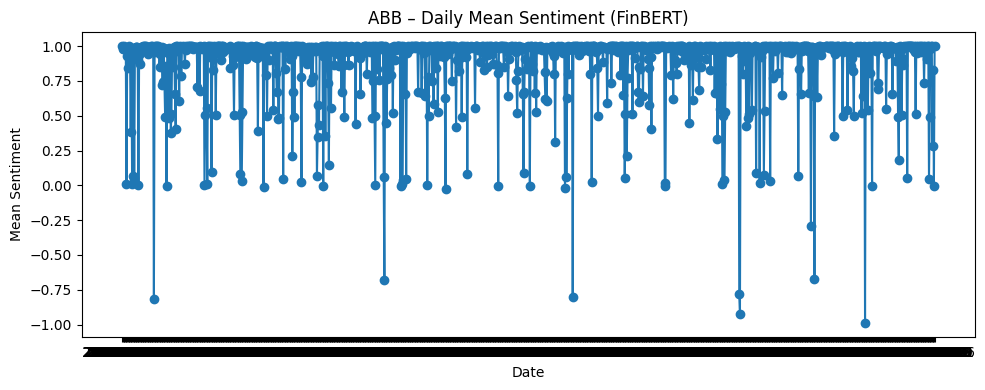

In [16]:
abb = daily_sent[daily_sent["ticker"]=="ABB"]

plt.figure(figsize=(10,4))
plt.plot(abb["date"], abb["sent_mean"], marker="o")
plt.title("ABB – Daily Mean Sentiment (FinBERT)")
plt.xlabel("Date")
plt.ylabel("Mean Sentiment")
plt.tight_layout()
plt.show()


In [17]:
def pick_daily_category(row):
    if row["sent_pos"] > row["sent_neg"]:
        return "positive"
    elif row["sent_neg"] > row["sent_pos"]:
        return "negative"
    else:
        return "neutral"

daily_sent["sent_daily_cat"] = daily_sent.apply(pick_daily_category, axis=1)

daily_sent.head(10)


,ticker,date,sent_mean,sent_std,sent_count,sent_pos,sent_neg,sent_neu,sent_lag1,sent_roll3,sent_daily_cat
0,ABB,2018-01-09,0.997986,0.000000,1,1,0,0,NaN,NaN,positive
1,ABB,2018-01-10,0.977620,0.006999,3,3,0,0,0.997986,0.997986,positive
2,ABB,2018-01-11,0.997827,0.004242,4,4,0,0,0.977620,0.987803,positive
3,ABB,2018-01-12,0.981021,0.018804,5,5,0,0,0.997827,0.991144,positive
4,ABB,2018-01-17,0.983361,0.023424,2,2,0,0,0.981021,0.985489,positive
5,ABB,2018-01-19,0.978925,0.017862,2,2,0,0,0.983361,0.987403,positive
6,ABB,2018-01-20,0.006744,0.000000,1,0,0,1,0.978925,0.981102,neutral
7,ABB,2018-01-23,0.929871,0.000000,1,1,0,0,0.006744,0.656343,positive
8,ABB,2018-01-24,0.842410,0.000000,1,1,0,0,0.929871,0.638514,positive
9,ABB,2018-01-25,0.992424,0.006619,4,4,0,0,0.842410,0.593008,positive


In [18]:
daily_sent.to_parquet("/content/drive/MyDrive/Colab Notebooks/sentiment_daily.parquet", index=False)


In [19]:
daily_sent.to_csv("/content/drive/MyDrive/Colab Notebooks/sentiment_daily.csv", index=False)